<a href="https://colab.research.google.com/github/chandu01432/Upskill/blob/main/Flight%20booking%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import warnings

warnings.filterwarnings('ignore')
# to clear some unwanted warining in your output

In [ ]:
df = pd.read_csv('/content/Flight_Booking.csv')

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
df = df.drop(columns =['Unnamed: 0'])

In [ ]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
df.shape

(300153, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df =df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(300153, 11)

In [ ]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


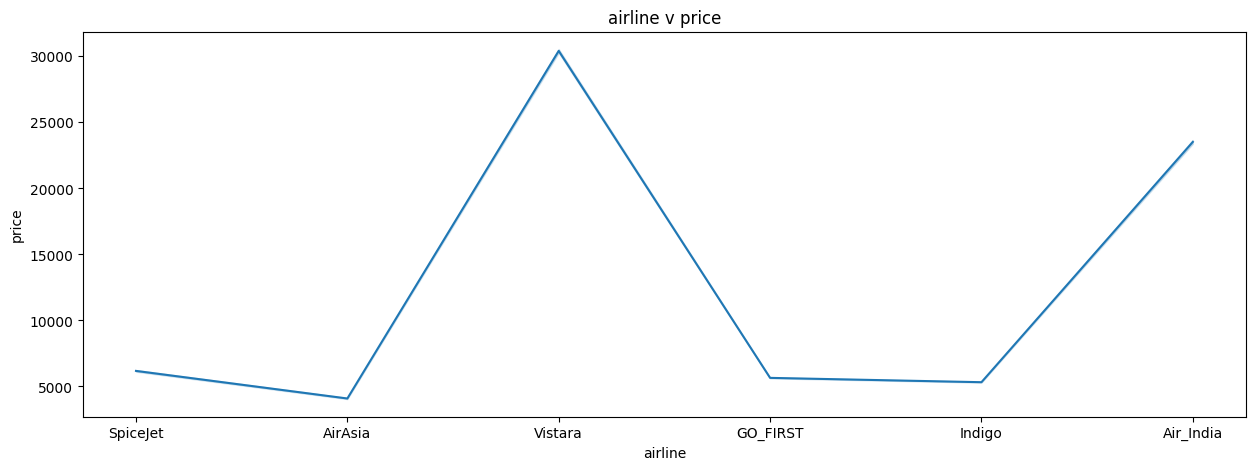

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(x = df['airline'], y =df['price'])
plt.title('airline v price')
plt.show()

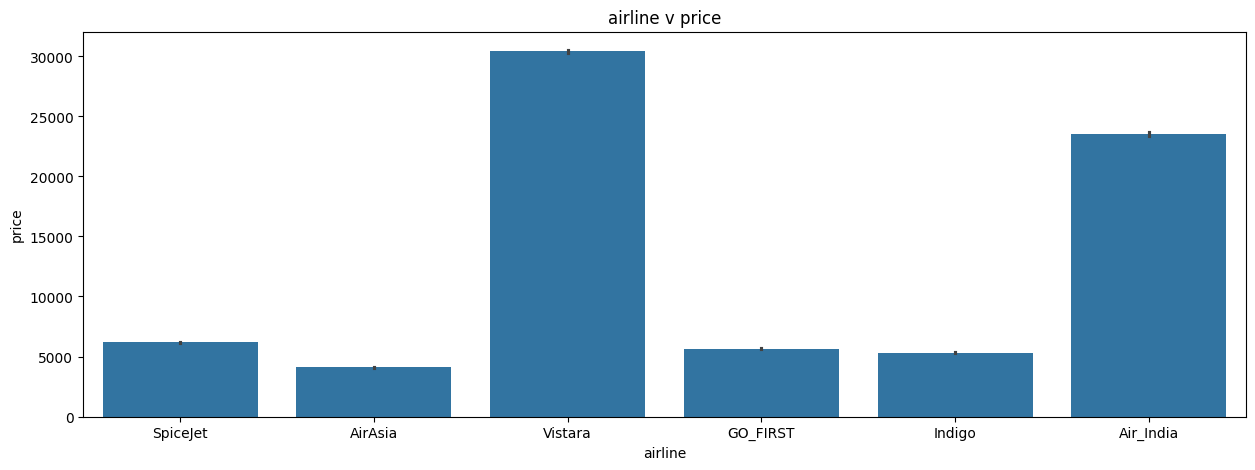

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(x = df['airline'], y =df['price'])
plt.title('airline v price')
plt.show()

<Axes: >

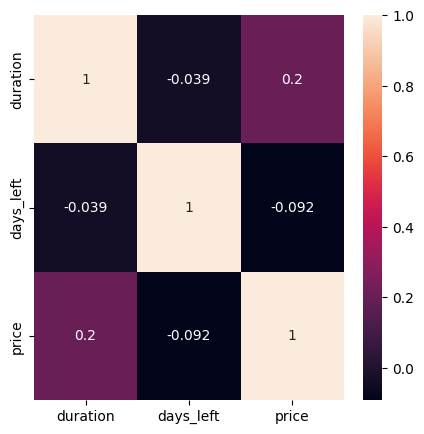

In [ ]:
plt.figure(figsize=(5,5))  # heatmap can only work with numerical data
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)

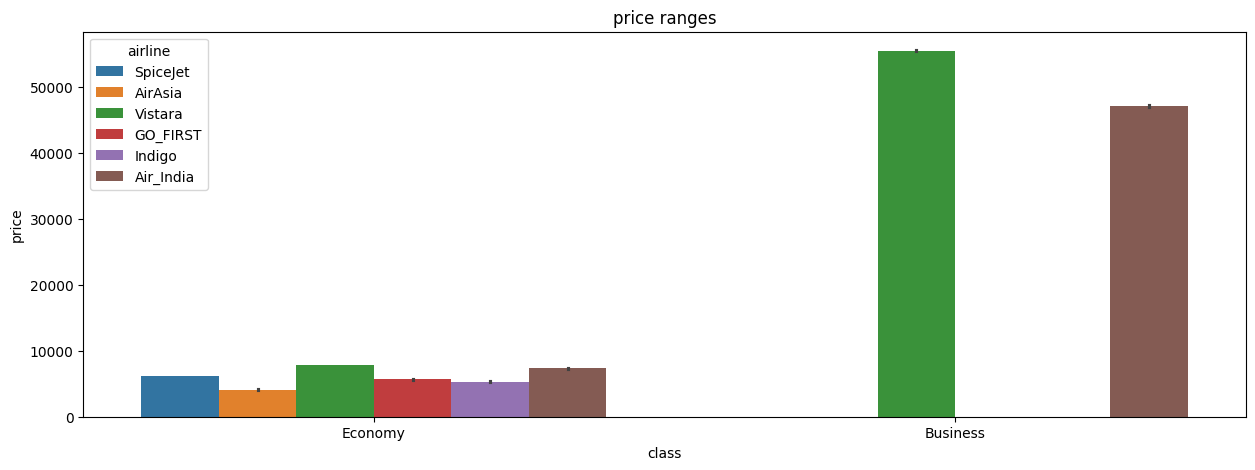

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(x ='class', y ='price',hue ='airline', data = df )
plt.title('price ranges')
plt.show()

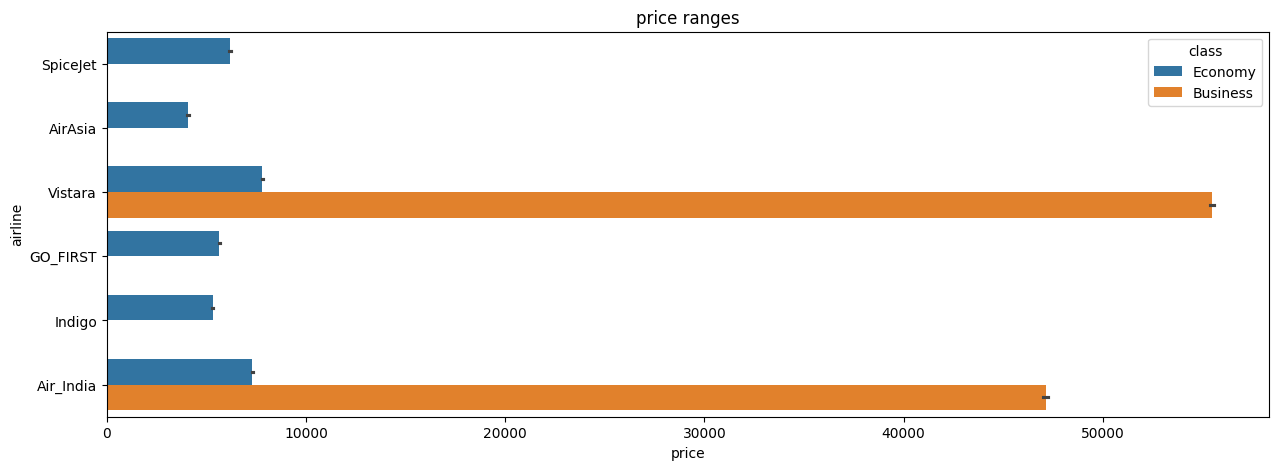

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(x ='price', y ='airline',hue ='class', data = df )
plt.title('price ranges')
plt.show()

In [ ]:
print(f"Economy Class Price Range: ${df[df['class'] == 'Economy']['price'].min():.2f} - ${df[df['class'] == 'Economy']['price'].max():.2f}")
print(f"Business Class Price Range: ${df[df['class'] == 'Business']['price'].min():.2f} - ${df[df['class'] == 'Business']['price'].max():.2f}")

Economy Class Price Range: $1105.00 - $42349.00
Business Class Price Range: $12000.00 - $123071.00


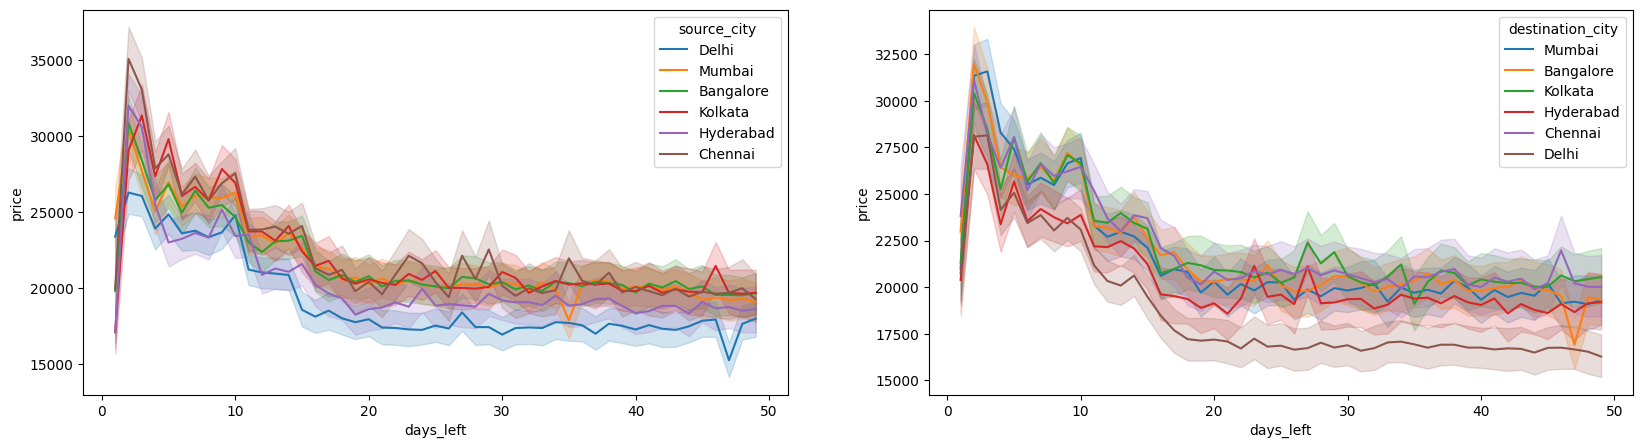

In [ ]:
fig, ax = plt.subplots(1,2, figsize =(20, 5))
sns.lineplot(x ='days_left', y ='price', hue ='source_city', data = df, ax = ax[0])
sns.lineplot(x = 'days_left', y ='price', hue ='destination_city', data = df, ax = ax[1])
plt.show()

In [ ]:
#Good evng everyone!
#Lets wait till 9:09 and then will start the session

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    df[col]=le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  int64  
 1   flight            300153 non-null  int64  
 2   source_city       300153 non-null  int64  
 3   departure_time    300153 non-null  int64  
 4   stops             300153 non-null  int64  
 5   arrival_time      300153 non-null  int64  
 6   destination_city  300153 non-null  int64  
 7   class             300153 non-null  int64  
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 25.2 MB


<Axes: >

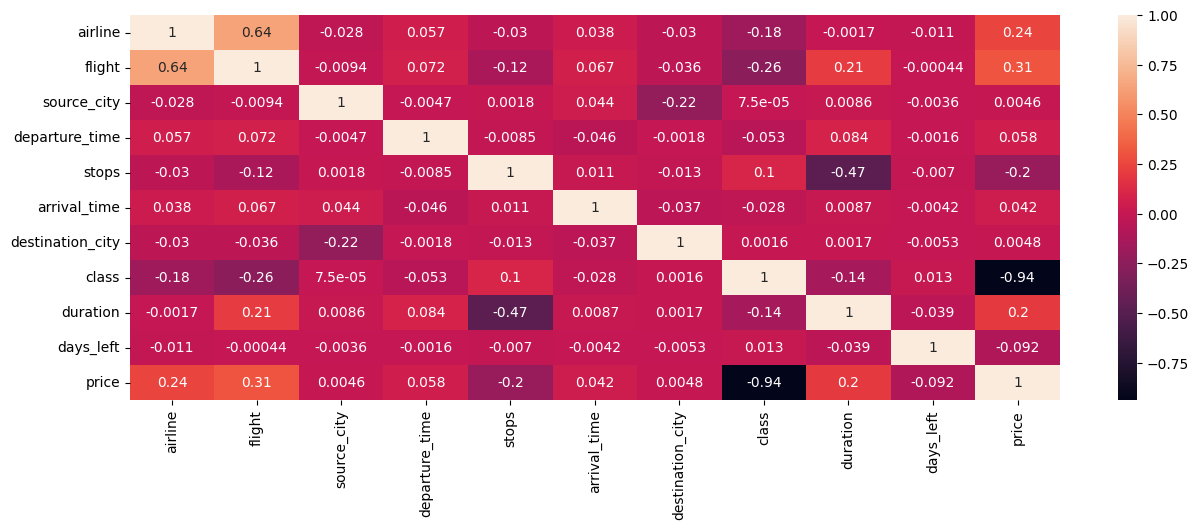

In [ ]:
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(),annot=True)

In [ ]:
y=df['price']
X=df.drop(['price'],axis=1)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,1408,2,2,2,5,5,1,2.17,1,5953
1,4,1387,2,1,2,4,5,1,2.33,1,5953
2,0,1213,2,1,2,1,5,1,2.17,1,5956
3,5,1559,2,4,2,0,5,1,2.25,1,5955
4,5,1549,2,4,2,4,5,1,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,0,10.08,49,69265
300149,5,1481,1,0,0,5,3,0,10.42,49,77105
300150,5,1486,1,1,0,5,3,0,13.83,49,79099
300151,5,1483,1,1,0,2,3,0,10.00,49,81585


In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] =X.columns

vif_values=[]

for i in range(len(X.columns)):
  vif= variance_inflation_factor(X_scaled,i)
  vif_values.append(vif)

vif_data['VIF'] = vif_values

In [ ]:
vif_data

,feature,VIF
0,airline,1.747041
1,flight,1.873489
2,source_city,1.055334
3,departure_time,1.016222
4,stops,1.296545
5,arrival_time,1.010501
6,destination_city,1.055304
7,class,1.084952
8,duration,1.386158
9,days_left,1.003083


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.20,random_state=45)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test_scaled)
y_pred

array([-1230.51248325, 41557.3488836 , 54889.86391343, ...,
        9230.41750741,  -898.21429185, 54360.65007879])

In [ ]:
from sklearn.metrics import *

In [ ]:
r2_score(y_test,y_pred)*100

90.33984038443865

In [ ]:
mean_squared_error(y_test,y_pred)

49764395.13635343

In [ ]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
rmse

np.float64(7054.388360187822)